# Chess Games Analysis - Final Project

This notebook performs exploratory data analysis (EDA), data wrangling, feature engineering, and hypothesis testing on a dataset of chess games from lichess.org.

## Table of Contents
1. **Setup & Data Loading** - Import libraries and load the dataset
2. **Data Understanding** - Initial exploration of the data
3. **Data Wrangling** - Cleaning and transforming the data
4. **Data Filtering** - Filtering data for specific analyses
5. **Data Visualization** - Visual exploration with plots
6. **Feature Engineering** - Creating and transforming features
7. **Hypothesis Testing** - Statistical tests to answer research questions

## 1. Setup & Data Loading

In [77]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Create images directory for saving figures
IMG_DIR = Path('images')
IMG_DIR.mkdir(exist_ok=True)

In [78]:
df = pd.read_csv('chess_games.csv')

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WhiteElo,6256184.0,1741.945305,265.717053,737.0,1559.0,1740.0,1919.0,3110.0
BlackElo,6256184.0,1740.390283,266.893806,728.0,1557.0,1739.0,1919.0,3108.0
WhiteRatingDiff,6251516.0,0.580262,22.851855,-595.0,-9.0,1.0,10.0,673.0
BlackRatingDiff,6251516.0,-0.367673,21.820124,-653.0,-10.0,-1.0,9.0,664.0


# About Dataset
## Context
Chess is one of the more famous board games of the world and one of the most studied. With it's more than 4 GB of information this can be a good opportunity to work with a huge dataset and practice on how to handle it.

## Content
This dataset contains 6.25 Million chess games played on lichess.org during July of 2016. Some of the games have Stockfish analysis evaluations like* [%eval 2.35] (235 centipawn advantage)* always from White's point of view. These are evaluations of the movement made by a player.

- Event: Game type. 
- White: White's ID. 
- Black: Black's ID. 
- Result: Game Result (1-0 White wins) (0-1 Black wins) 
- UTCDate: UTC Date. 
- UTCTime: UTC Time. 
- WhiteElo: White's ELO. 
- BlackElo: Black's ELO. 
- WhiteRatingDiff: White's rating points difference after the game. 
- BlackRatingDiff: Blacks's rating points difference after the game. 
- ECO: Opening in ECO encoding. 
- Opening: Opening name. 
- TimeControl: Time of the game for each player in seconds. The number after the increment is the number of seconds before the player's clock starts ticking in each turn. 
- Termination: Reason of the game's end. - AN: Movements in Movetext format.

Acknowledgements
The original data has been published by lichess.org.

## 2. Data Understanding

Let's explore the structure and basic properties of our dataset.

In [80]:
# Basic dataset info
print(f"Number of rows: {df.shape[0]}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Number of rows: 6256184

Column names:
['Event', 'White', 'Black', 'Result', 'UTCDate', 'UTCTime', 'WhiteElo', 'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'ECO', 'Opening', 'TimeControl', 'Termination', 'AN']

Data types:
Event               object
White               object
Black               object
Result              object
UTCDate             object
UTCTime             object
WhiteElo             int64
BlackElo             int64
WhiteRatingDiff    float64
BlackRatingDiff    float64
ECO                 object
Opening             object
TimeControl         object
Termination         object
AN                  object
dtype: object


In [81]:
# Sample 500,000 rows for faster processing
df = df.sample(n=500000, random_state=42).reset_index(drop=True)
print(f"Sample shape: {df.shape}")

Sample shape: (500000, 15)


In [82]:
# Preview categorical columns
df.select_dtypes(include='object').head()

,Event,White,Black,Result,UTCDate,UTCTime,ECO,Opening,TimeControl,Termination,AN
0,Blitz tournament,antonin32,TheMasterClass,1-0,2016.07.14,08:39:44,C00,Rat Defense: Small Center Defense,180+0,Normal,1. e4 d6 2. d4 e6 3. Nf3 Qh4 4. g3 Qxe4+ 5. Qe...
1,Blitz,MACFLAIR,Rodrigo_Inacio,0-1,2016.07.10,02:27:48,A01,Nimzo-Larsen Attack: Modern Variation #4,300+0,Normal,1. b3 e5 2. Bb2 Nc6 3. e3 d5 4. Bb5 Bd7 5. Bxc...
2,Blitz,dflbv50,RompoOrtosYDefensas,0-1,2016.07.10,11:10:48,C00,Rat Defense: Small Center Defense,180+0,Normal,1. e4 d6 2. d4 e6 3. c4 f6 4. Nc3 g6 5. Nf3 Bg...
3,Classical,yjunior5000,Syas,1-0,2016.07.12,22:58:08,A50,Slav Indian,420+8,Normal,1. c4 Nf6 2. d4 c6 3. Nc3 d5 4. c5 Bf5 5. Nf3 ...
4,Bullet,mrzlopolis2,munizbc,0-1,2016.07.16,19:30:03,B10,Caro-Kann Defense: Breyer Variation,30+0,Time forfeit,1. e4 c6 2. d3 d5 3. Be2 dxe4 4. dxe4 Qxd1+ 5....


In [83]:
# Check for missing values
df.isnull().sum()

Event                0
White                0
Black                0
Result               0
UTCDate              0
UTCTime              0
WhiteElo             0
BlackElo             0
WhiteRatingDiff    364
BlackRatingDiff    364
ECO                  0
Opening              0
TimeControl          0
Termination          0
AN                   0
dtype: int64

## 3. Data Wrangling

In this section, we clean and transform the data to prepare it for analysis.

### 3.1 Selecting and Renaming Columns

Below, we are filtering our data, by selecting only the relevant columns. Also, we are using the `rename()` method to change the name of the columns.

In [84]:
# Select relevant columns and rename for clarity
data = df[['Event', 'Result', 'ECO', 'Opening', 'TimeControl', 
           'Termination', 'UTCDate', 'WhiteElo', 'BlackElo']].copy()

data = data.rename(columns={
    'UTCDate': 'Date', 
    'ECO': 'Opening Code', 
    'Opening': 'Variation'
})

data.head()

,Event,Result,Opening Code,Variation,TimeControl,Termination,Date,WhiteElo,BlackElo
0,Blitz tournament,1-0,C00,Rat Defense: Small Center Defense,180+0,Normal,2016.07.14,1657,1475
1,Blitz,0-1,A01,Nimzo-Larsen Attack: Modern Variation #4,300+0,Normal,2016.07.10,1516,1592
2,Blitz,0-1,C00,Rat Defense: Small Center Defense,180+0,Normal,2016.07.10,2045,1980
3,Classical,1-0,A50,Slav Indian,420+8,Normal,2016.07.12,1724,1863
4,Bullet,0-1,B10,Caro-Kann Defense: Breyer Variation,30+0,Time forfeit,2016.07.16,1894,2014


Converting the date column to datetime format and extracting temporal features.

In [85]:
data['Date'] = pd.to_datetime(data['Date'], format='%Y.%m.%d') #, errors='coerce'

In [86]:
data['Month'] = data['Date'].dt.month_name().str.slice(stop=3)
data['Year'] = data['Date'].dt.year

In [87]:
data.head()

,Event,Result,Opening Code,Variation,TimeControl,Termination,Date,WhiteElo,BlackElo,Month,Year
0,Blitz tournament,1-0,C00,Rat Defense: Small Center Defense,180+0,Normal,2016-07-14,1657,1475,Jul,2016
1,Blitz,0-1,A01,Nimzo-Larsen Attack: Modern Variation #4,300+0,Normal,2016-07-10,1516,1592,Jul,2016
2,Blitz,0-1,C00,Rat Defense: Small Center Defense,180+0,Normal,2016-07-10,2045,1980,Jul,2016
3,Classical,1-0,A50,Slav Indian,420+8,Normal,2016-07-12,1724,1863,Jul,2016
4,Bullet,0-1,B10,Caro-Kann Defense: Breyer Variation,30+0,Time forfeit,2016-07-16,1894,2014,Jul,2016


Checking the summary statistics of numeric features.

In [88]:
data.describe().T 

,count,mean,min,25%,50%,75%,max,std
Date,500000,2016-07-16 01:08:49.401600,2016-06-30 00:00:00,2016-07-08 00:00:00,2016-07-16 00:00:00,2016-07-24 00:00:00,2016-07-31 00:00:00,NaN
WhiteElo,500000.0,1742.257174,762.0,1559.0,1740.0,1920.0,3006.0,266.111126
BlackElo,500000.0,1740.618672,778.0,1557.0,1739.0,1919.0,3099.0,267.500926
Year,500000.0,2016.0,2016.0,2016.0,2016.0,2016.0,2016.0,0.0


The date columns show very limited variation (all data is from July 2016), so they don't add information value. We'll drop these columns.

In [89]:
data = data.drop(columns=['Date', 'Month', 'Year'])

### 3.2 Exploring and Cleaning Categorical Variables

Let's examine each categorical variable and handle any data quality issues.

#### Event (Game Type)
Exploring the different game types in the dataset.

In [90]:
data.Event.unique().tolist()

[' Blitz tournament ',
 ' Blitz ',
 ' Classical ',
 ' Bullet ',
 ' Bullet tournament ',
 ' Classical tournament ',
 ' Correspondence ',
 'Blitz ',
 'Blitz tournament ',
 'Bullet tournament ']

We need to fix apparently duplicated values caused by leading/trailing whitespace.

In [91]:
# Remove leading/trailing whitespace
data['Event'] = data['Event'].str.strip()
data['Event'].unique().tolist()

['Blitz tournament',
 'Blitz',
 'Classical',
 'Bullet',
 'Bullet tournament',
 'Classical tournament',
 'Correspondence']

#### Result (Game Outcome)
Exploring the possible game outcomes.

In [92]:
data.Result.unique().tolist()

['1-0', '0-1', '1/2-1/2', '*']

In [93]:
data.Result.value_counts() 

Result
1-0        249227
0-1        231669
1/2-1/2     19000
*             104
Name: count, dtype: int64

We will remove observations with invalid results (marked with `*`).

In [94]:
# Remove invalid game results
data = data[data['Result'] != '*']
data['Result'].value_counts()

Result
1-0        249227
0-1        231669
1/2-1/2     19000
Name: count, dtype: int64

#### Opening Code (ECO)
Exploring the ECO (Encyclopaedia of Chess Openings) codes.

In [95]:
data['Opening Code'].unique().tolist()

['C00',
 'A01',
 'A50',
 'B10',
 'C02',
 'B01',
 'C61',
 'A48',
 'C24',
 'A00',
 'C01',
 'C41',
 'C65',
 'B02',
 'D02',
 'C10',
 'B50',
 'D00',
 'A40',
 'A14',
 'A56',
 'B00',
 'B23',
 'D30',
 'C45',
 'B07',
 'C59',
 'D01',
 'C66',
 'C40',
 'A04',
 'A45',
 'C55',
 'D10',
 'B20',
 'C33',
 'C50',
 'C64',
 'A81',
 'B30',
 'D11',
 'C48',
 'B31',
 'C21',
 'C57',
 'B22',
 'C20',
 'D20',
 'A46',
 'C26',
 'B45',
 'B27',
 'C42',
 'B11',
 'C28',
 'B90',
 'A43',
 'A10',
 'A02',
 'B25',
 'B56',
 'B06',
 'C43',
 'D05',
 'C44',
 'C46',
 'A80',
 'B73',
 'A21',
 'C34',
 'D06',
 'B40',
 'C54',
 'B32',
 'C11',
 'D50',
 'E54',
 'A16',
 'D89',
 'D31',
 'B21',
 'B76',
 'A07',
 'A63',
 'E14',
 'D32',
 'C13',
 'B12',
 'A41',
 'E22',
 'C23',
 'B51',
 'A42',
 'A22',
 'B72',
 'A49',
 'B15',
 'C30',
 'C53',
 'D46',
 'C17',
 'D85',
 'D12',
 'E32',
 'C70',
 'D45',
 'E20',
 'B92',
 'E30',
 'C25',
 'E70',
 'A06',
 'C38',
 'A54',
 'C16',
 'C05',
 'B08',
 'D44',
 'B03',
 'C27',
 'A17',
 'E72',
 'C88',
 'C58',
 'A11',


Extracting the main opening group (A, B, C, D, E) from the ECO code.

In [96]:
# Extract opening group letter (A-E)
data['eco_group'] = data['Opening Code'].str[0]
data = data.drop(columns='Opening Code')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499896 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Event        499896 non-null  object
 1   Result       499896 non-null  object
 2   Variation    499896 non-null  object
 3   TimeControl  499896 non-null  object
 4   Termination  499896 non-null  object
 5   WhiteElo     499896 non-null  int64 
 6   BlackElo     499896 non-null  int64 
 7   eco_group    499896 non-null  object
dtypes: int64(2), object(6)
memory usage: 34.3+ MB


#### Variation (Opening Name)
Exploring the different opening variations played.

In [97]:
data.Variation.unique().tolist()

['Rat Defense: Small Center Defense',
 'Nimzo-Larsen Attack: Modern Variation #4',
 'Slav Indian',
 'Caro-Kann Defense: Breyer Variation',
 'French Defense: Advance Variation, Nimzowitsch System',
 'Nimzo-Larsen Attack: English Variation',
 'Scandinavian Defense',
 'Ruy Lopez: Bird Variation',
 "Indian Game: Colle System, King's Indian Variation",
 "Bishop's Opening: Berlin Defense",
 "Van't Kruijs Opening",
 'French Defense: Exchange Variation',
 'Philidor Defense #2',
 'Ruy Lopez: Berlin Defense #2',
 'Alekhine Defense: Scandinavian Variation',
 "Queen's Pawn Game: Zukertort Variation",
 'French Defense: Paulsen Variation',
 'Sicilian Defense',
 "Queen's Pawn Game: Chigorin Variation",
 'Horwitz Defense',
 'English Opening: Agincourt Defense, Neo-Catalan Declined',
 'Scandinavian Defense: Modern Variation #2',
 'Benoni Defense',
 'St. George Defense',
 "Queen's Pawn Game",
 'Sicilian Defense: Closed',
 "Queen's Gambit Declined",
 'French Defense #2',
 'Hungarian Opening: Catalan Form

In [98]:
data['Variation'].value_counts()

Variation
Van't Kruijs Opening                                                 10672
Scandinavian Defense: Mieses-Kotroc Variation                         9026
Modern Defense                                                        8624
Horwitz Defense                                                       7591
Sicilian Defense                                                      6774
                                                                     ...  
Hippopotamus Defense                                                     1
Gruenfeld Defense: Russian Variation, Byrne (Simagin) Variation          1
King's Indian Defense: Averbakh Variation, Modern Defense                1
Zukertort Defense: Drunken Cavalry Variation                             1
Nimzo-Indian Defense: 4.e3, Main Line, with 8...dxc4 and 9...cxd4        1
Name: count, Length: 2556, dtype: int64

We will replace rare opening variations with 'Other' to reduce cardinality.

In [99]:
# Keep top 20 variations, replace others with 'Other'
top_variants = data['Variation'].value_counts().nlargest(20).index
data['variation_clean'] = data['Variation'].where(data['Variation'].isin(top_variants), 'Other')

In [100]:
data['variation_clean'].nunique()

21

#### Time Control
Exploring the time control settings (format: base_time+increment).

The game pace (e.g., "10+0", "3+2", "180+2") should be treated as numeric data, not categorical.

In [101]:
data['TimeControl'].unique().tolist()

['180+0',
 '300+0',
 '420+8',
 '30+0',
 '0+4',
 '420+3',
 '120+0',
 '120+8',
 '60+0',
 '600+0',
 '180+1',
 '120+2',
 '600+3',
 '360+0',
 '600+8',
 '300+1',
 '900+0',
 '3600+0',
 '900+10',
 '360+3',
 '1200+5',
 '300+5',
 '300+4',
 '1800+0',
 '180+2',
 '300+15',
 '300+2',
 '300+3',
 '0+1',
 '1200+0',
 '480+8',
 '720+0',
 '900+15',
 '480+0',
 '180+5',
 '900+3',
 '300+8',
 '60+2',
 '480+2',
 '420+7',
 '180+10',
 '420+0',
 '540+14',
 '240+1',
 '540+20',
 '480+1',
 '30+1',
 '300+7',
 '30+2',
 '120+12',
 '120+3',
 '780+12',
 '600+4',
 '900+5',
 '1800+8',
 '1500+5',
 '60+1',
 '120+1',
 '420+1',
 '360+8',
 '0+3',
 '1500+0',
 '540+5',
 '600+5',
 '180+8',
 '300+6',
 '360+1',
 '420+2',
 '480+6',
 '0+15',
 '300+10',
 '0+2',
 '900+6',
 '360+9',
 '540+0',
 '240+0',
 '600+15',
 '1500+7',
 '240+4',
 '600+30',
 '240+3',
 '600+2',
 '360+5',
 '1200+2',
 '720+5',
 '960+10',
 '45+2',
 '120+10',
 '780+6',
 '45+3',
 '90+2',
 '-',
 '660+0',
 '240+20',
 '120+9',
 '600+10',
 '1140+0',
 '600+6',
 '360+10',
 '480+

In [102]:
data['TimeControl'].value_counts()

TimeControl
300+0       85762
180+0       75748
60+0        72778
600+0       46681
30+0        24527
            ...  
2100+180        1
600+35          1
2400+3          1
30+7            1
720+16          1
Name: count, Length: 632, dtype: int64

We will split the TimeControl into two numeric columns: `base_time` (initial time in seconds) and `increment` (seconds added per move).

Example: "3+2" becomes base_time=3 and increment=2.

In [103]:
def parse_time(tc):
    """Parse TimeControl string into base time and increment."""
    if '+' in str(tc):
        try:
            base, inc = tc.split('+')
            return int(base), int(inc)
        except:
            return 0, 0
    return 0, 0

# Apply parsing to create numeric columns
times = np.array([parse_time(x) for x in data['TimeControl']])
data['base_time'] = times[:, 0].astype(np.int32)
data['increment'] = times[:, 1].astype(np.int32)

In [104]:
data.head()

,Event,Result,Variation,TimeControl,Termination,WhiteElo,BlackElo,eco_group,variation_clean,base_time,increment
0,Blitz tournament,1-0,Rat Defense: Small Center Defense,180+0,Normal,1657,1475,C,Other,180,0
1,Blitz,0-1,Nimzo-Larsen Attack: Modern Variation #4,300+0,Normal,1516,1592,A,Other,300,0
2,Blitz,0-1,Rat Defense: Small Center Defense,180+0,Normal,2045,1980,C,Other,180,0
3,Classical,1-0,Slav Indian,420+8,Normal,1724,1863,A,Other,420,8
4,Bullet,0-1,Caro-Kann Defense: Breyer Variation,30+0,Time forfeit,1894,2014,B,Other,30,0


In [105]:
data[data['TimeControl']=='-'].value_counts().sum()

1920

In [106]:
data['TimeControl'] = data['TimeControl'].replace('-', 'other')
data['TimeControl'].value_counts()

TimeControl
300+0       85762
180+0       75748
60+0        72778
600+0       46681
30+0        24527
            ...  
2100+180        1
600+35          1
2400+3          1
30+7            1
720+16          1
Name: count, Length: 632, dtype: int64

In [107]:
# Drop the original TimeControl column
data.drop(columns=['TimeControl'], inplace=True)

## 4. Data Filtering

Applying filters to create subsets of data for specific analyses.

### 4.1 Filtering High-Elo Games
Selecting games where both players have an Elo rating above a threshold.

In [108]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
WhiteElo,499896.0,1742.255167,266.111731,762.0,1559.0,1740.0,1920.0,3006.0
BlackElo,499896.0,1740.610703,267.500565,778.0,1557.0,1739.0,1919.0,3099.0
base_time,499896.0,311.809286,396.392389,0.0,120.0,240.0,300.0,10800.0
increment,499896.0,1.198453,4.225287,0.0,0.0,0.0,1.0,180.0


Let's assume 1920 is the minimum Elo rating to be considered "high."

In [109]:
high_elo_openings = data[(data["WhiteElo"] >= 1920) & (data["BlackElo"] >= 1920)]
high_elo_openings.head()

,Event,Result,Variation,Termination,WhiteElo,BlackElo,eco_group,variation_clean,base_time,increment
2,Blitz,0-1,Rat Defense: Small Center Defense,Normal,2045,1980,C,Other,180,0
15,Blitz,1/2-1/2,Ruy Lopez: Berlin Defense #2,Normal,1949,1976,C,Other,300,0
16,Blitz,0-1,Alekhine Defense: Scandinavian Variation,Normal,1925,2170,B,Other,180,1
22,Bullet,1-0,"English Opening: Agincourt Defense, Neo-Catala...",Normal,2465,2099,A,Other,60,0
32,Bullet tournament,1-0,Owen Defense,Normal,2418,2013,B,Owen Defense,30,0


### 4.2 Aggregating by Opening Variation
Calculating mean Elo for each opening variation among high-rated players.

In [110]:
group_high_elo_openings_white = high_elo_openings.groupby(['Variation'])['WhiteElo'].mean()
group_high_elo_openings_black = high_elo_openings.groupby(['Variation'])['BlackElo'].mean()

In [111]:
group_high_elo_openings_white.sort_values(ascending=False)

Variation
Neo-Gruenfeld Defense: Delayed Exchange Variation #2                            2708.0
Lion Defense: Bayonet Attack                                                    2598.0
King's Gambit Accepted, Kieseritzky Gambit, Rubinstein Variation                2577.0
Queen's Gambit Declined: Harrwitz Attack, Two Knights Defense, Blockade Line    2553.0
Semi-Slav Defense: Meran Variation, Blumenfeld Variation                        2526.0
                                                                                 ...  
Sicilian Defense: Yates Variation                                               1925.0
Blackmar-Diemer Gambit: Diemer-Rosenberg Attack                                 1925.0
Four Knights Game: Scotch Variation, Schmid Defense                             1923.0
Polish Opening: Baltic Defense                                                  1921.0
English Orangutan                                                               1920.0
Name: WhiteElo, Length: 2225, dty

In [112]:
group_high_elo_openings_black.sort_values(ascending=False)

Variation
Queen's Indian Defense: Petrosian Variation, Farago Defense                     2647.0
Veresov Opening: Malich Gambit                                                  2640.0
Catalan Opening: Open Defense, Modern Sharp Variation                           2626.0
Queen's Gambit Declined: Harrwitz Attack, Two Knights Defense, Blockade Line    2594.5
Modern Defense: Semi-Averbakh Variation, Pterodactyl Variation                  2531.0
                                                                                 ...  
Latvian Gambit Accepted, Foltys-Leonhardt Variation                             1926.0
French Defense: Franco-Hiva Gambit II                                           1924.0
English Orangutan                                                               1924.0
Englund Gambit Complex: Zilbermints Gambit II                                   1923.0
King's Gambit: Panteldakis Countergambit                                        1920.0
Name: BlackElo, Length: 2225, dty

## 5. Data Visualization

Visual exploration of the data using histograms, boxplots, and other charts.

### 5.1 Histograms
Visualizing the distribution of rating (Elo) and time control features.

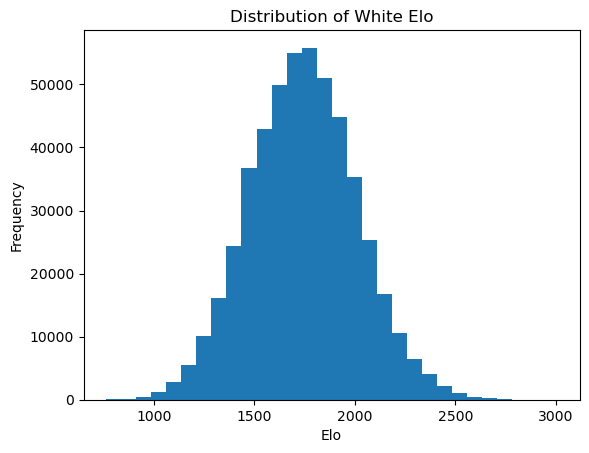

In [113]:
fig, ax = plt.subplots()
ax.hist(data.WhiteElo, bins=30)
ax.set(xlabel='Elo',
       ylabel='Frequency',
       title='Distribution of White Elo')
plt.savefig(IMG_DIR / '01_white_elo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

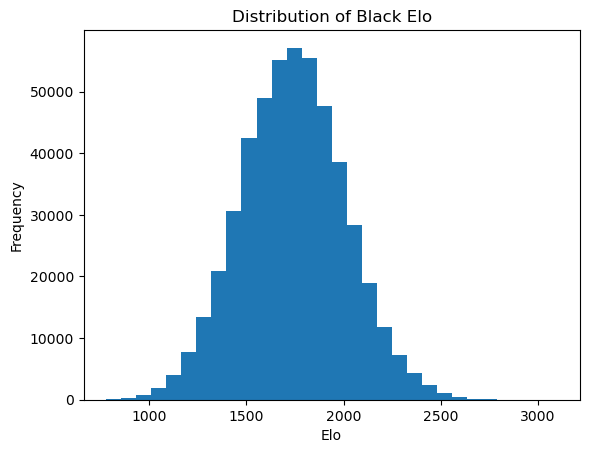

In [114]:
fig, ax = plt.subplots()
ax.hist(data.BlackElo, bins=30)
ax.set(xlabel='Elo',
       ylabel='Frequency',
       title='Distribution of Black Elo')
plt.savefig(IMG_DIR / '02_black_elo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

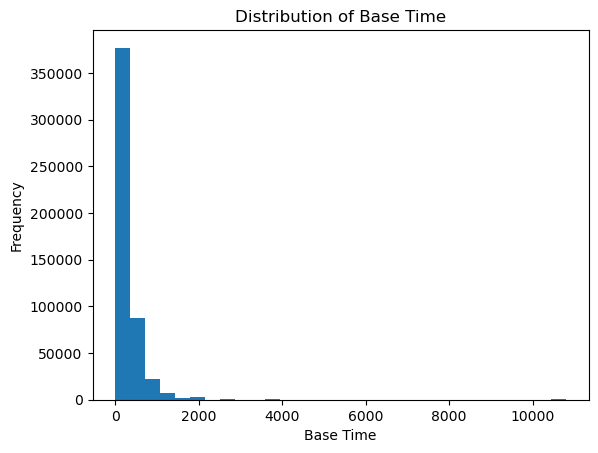

In [115]:
fig, ax = plt.subplots()
ax.hist(data.base_time, bins=30)
ax.set(xlabel='Base Time',
       ylabel='Frequency',
       title='Distribution of Base Time')
plt.savefig(IMG_DIR / '03_base_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Boxplots
Visualizing the distribution and outliers using boxplots.

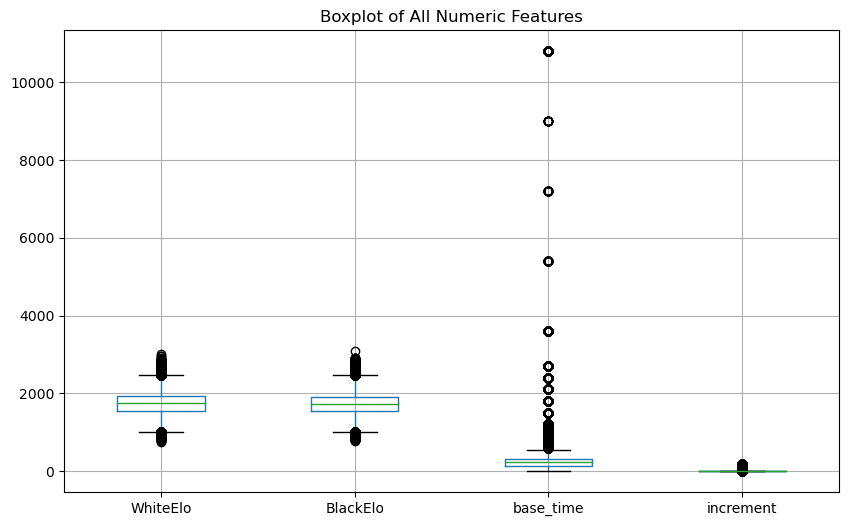

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))
data.boxplot(ax=ax)
plt.title('Boxplot of All Numeric Features')
plt.savefig(IMG_DIR / '04_boxplot_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\super\AppData\Local\Temp\ipykernel_27404\3817153766.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.boxplot(by='Event', ax=ax)


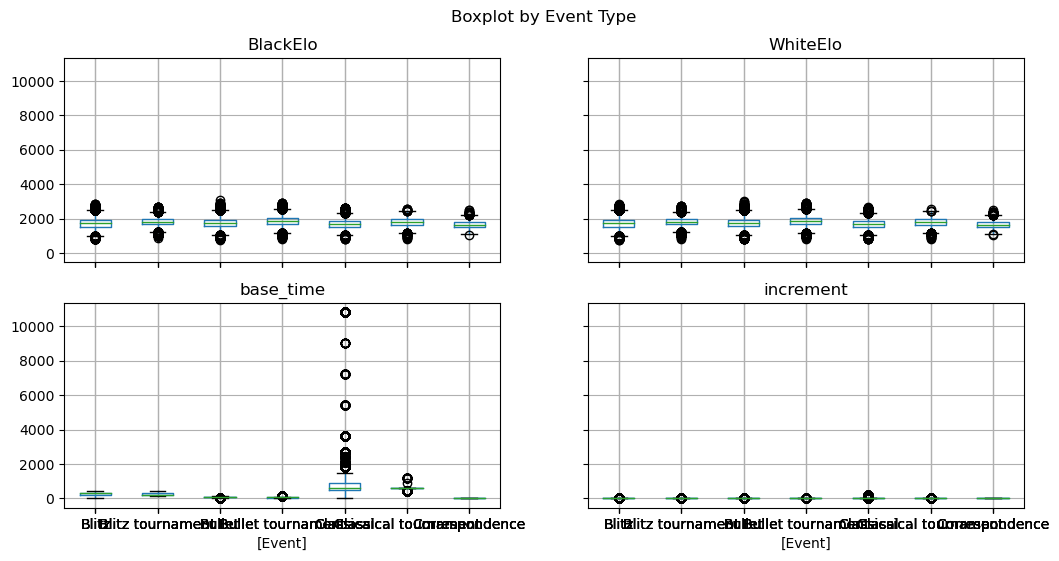

In [117]:
fig, ax = plt.subplots(figsize=(12, 6))
data.boxplot(by='Event', ax=ax)
plt.suptitle('Boxplot by Event Type')
plt.savefig(IMG_DIR / '05_boxplot_by_event.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering

Preparing the data for modeling by encoding categorical variables and transforming skewed features.

### 6.1 One-Hot Encoding

Converting categorical variables to dummy/indicator variables for modeling.

In [118]:
data.drop(columns='Variation', inplace=True)

In [119]:
# Identify categorical columns (object dtype)
one_hot_encode_cols = data.select_dtypes(include='object').columns.tolist()

In [120]:
data[one_hot_encode_cols].head()

,Event,Result,Termination,eco_group,variation_clean
0,Blitz tournament,1-0,Normal,C,Other
1,Blitz,0-1,Normal,A,Other
2,Blitz,0-1,Normal,C,Other
3,Classical,1-0,Normal,A,Other
4,Bullet,0-1,Time forfeit,B,Other


In [121]:
one_hot_encode_cols.remove('Result')

In [122]:
# Do the one hot encoding
data = pd.get_dummies(data, columns=one_hot_encode_cols, drop_first=True)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
WhiteElo,499896.0,1742.255167,266.111731,762.0,1559.0,1740.0,1920.0,3006.0
BlackElo,499896.0,1740.610703,267.500565,778.0,1557.0,1739.0,1919.0,3099.0
base_time,499896.0,311.809286,396.392389,0.0,120.0,240.0,300.0,10800.0
increment,499896.0,1.198453,4.225287,0.0,0.0,0.0,1.0,180.0


In [123]:
# Label encoding for the 'Result' feature
mapping = {
    '0-1': 0,   # Black wins
    '1/2-1/2': 1,  # Draw
    '1-0': 2    # White wins
}

data['Result'] = data['Result'].map(mapping)

In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499896 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column                                                         Non-Null Count   Dtype
---  ------                                                         --------------   -----
 0   Result                                                         499896 non-null  int64
 1   WhiteElo                                                       499896 non-null  int64
 2   BlackElo                                                       499896 non-null  int64
 3   base_time                                                      499896 non-null  int32
 4   increment                                                      499896 non-null  int32
 5   Event_Blitz tournament                                         499896 non-null  bool 
 6   Event_Bullet                                                   499896 non-null  bool 
 7   Event_Bullet tournament                                        499896 

### 6.2 Log Transformation for Skewed Variables

Applying log transformation to reduce skewness in numeric features.

In [125]:
# Identify integer columns to check for skewness
int_cols = data.select_dtypes(include='int').columns

# Define skewness threshold
skew_limit = 0.75
skew_vals = data[int_cols].skew()

In [126]:
skew_vals

Result       -0.070249
WhiteElo      0.088051
BlackElo      0.088854
base_time    11.644740
increment    23.464448
dtype: float64

In [127]:
# Showing the skewed columns
skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {}'.format(skew_limit)))

skew_cols

,Skew
increment,23.464448
base_time,11.644740


Visualizing the before/after effect of `np.log1p` transformation on skewed features.

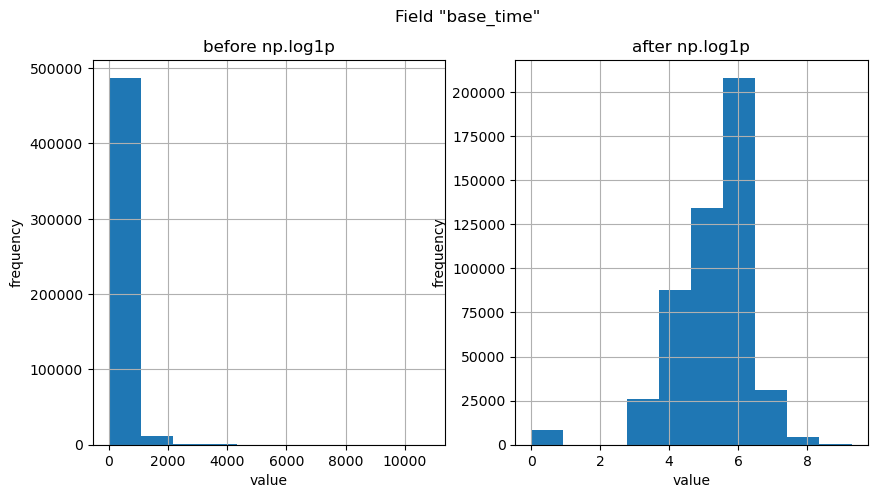

In [128]:
# Create two "subplots" and a "figure" using matplotlib
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))

data['base_time'].hist(ax=ax_before)
data['base_time'].apply(np.log1p).hist(ax=ax_after)

ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')
fig.suptitle('Field "{}"'.format('base_time'))
plt.savefig(IMG_DIR / '06_log_transform_base_time.png', dpi=150, bbox_inches='tight')
plt.show()

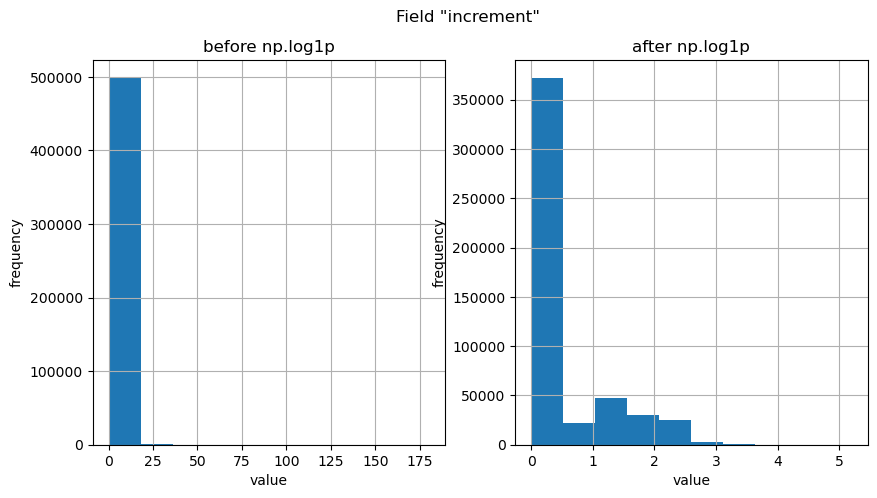

In [129]:
# Create two "subplots" and a "figure" using matplotlib
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))

data['increment'].hist(ax=ax_before)
data['increment'].apply(np.log1p).hist(ax=ax_after)

ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')
fig.suptitle('Field "{}"'.format('increment'))
plt.savefig(IMG_DIR / '07_log_transform_increment.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Applying the skew transformation:

for col in skew_cols.index.values:
    data[col] = data[col].apply(np.log1p)

### 6.3 Feature Relationships

Exploring relationships between key features using pair plots and correlation analysis.

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499896 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   Result                                                         499896 non-null  int64  
 1   WhiteElo                                                       499896 non-null  int64  
 2   BlackElo                                                       499896 non-null  int64  
 3   base_time                                                      499896 non-null  float64
 4   increment                                                      499896 non-null  float64
 5   Event_Blitz tournament                                         499896 non-null  bool   
 6   Event_Bullet                                                   499896 non-null  bool   
 7   Event_Bullet tournament                             

In [132]:
smaller_data = data.loc[:,['Result','WhiteElo','BlackElo','base_time','increment']]

In [133]:
smaller_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499896 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Result     499896 non-null  int64  
 1   WhiteElo   499896 non-null  int64  
 2   BlackElo   499896 non-null  int64  
 3   base_time  499896 non-null  float64
 4   increment  499896 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 22.9 MB


c:\Users\super\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\super\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\super\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\super\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

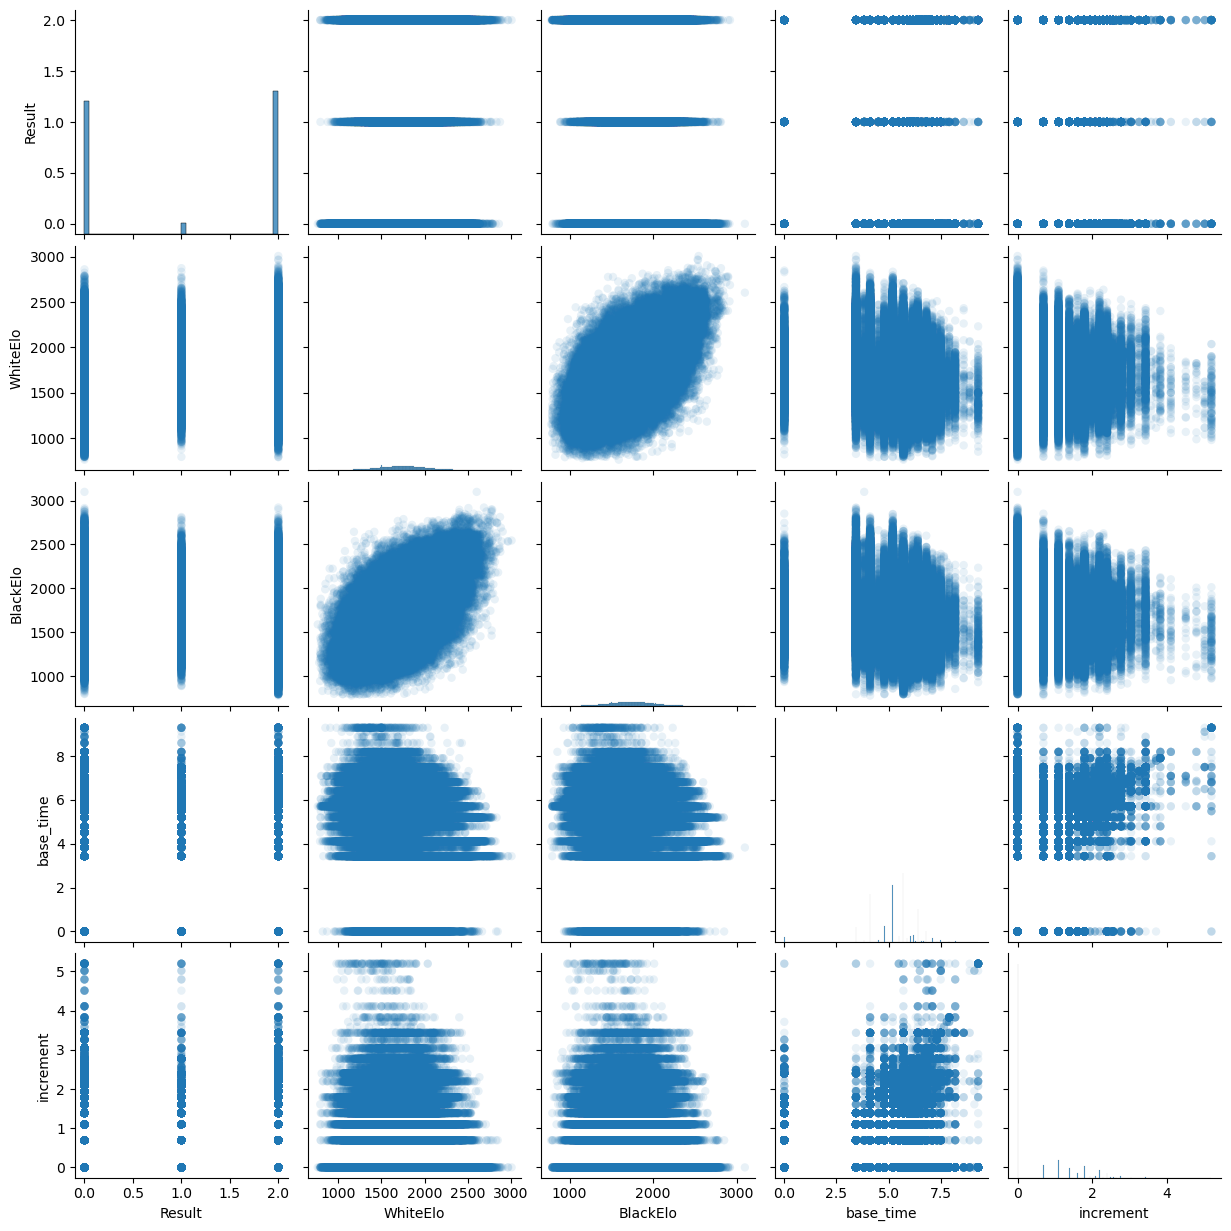

In [134]:
g = sns.pairplot(smaller_data, plot_kws=dict(alpha=.1, edgecolor='none'))
g.savefig(IMG_DIR / '08_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

Result                                                           1.000000
WhiteElo                                                         0.136736
Termination_Normal                                               0.019558
eco_group_D                                                      0.017438
eco_group_C                                                      0.016544
variation_clean_Scandinavian Defense: Mieses-Kotroc Variation    0.014346
variation_clean_Philidor Defense #3                              0.014008
variation_clean_Other                                            0.013984
variation_clean_Queen's Pawn                                     0.009437
variation_clean_Scotch Game                                      0.009415
base_time                                                        0.006005
Event_Classical                                                  0.005465
variation_clean_Queen's Pawn Game: Chigorin Variation            0.005148
Termination_Rules infraction          

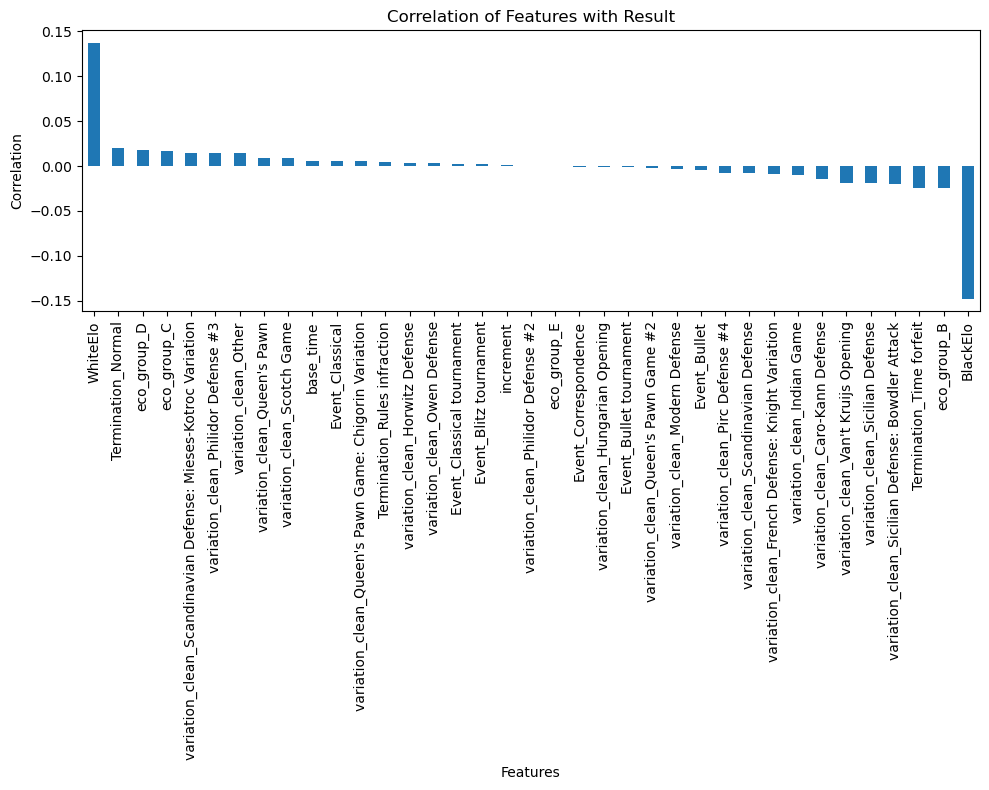

In [135]:
correlation = data.corr()['Result'].sort_values(ascending=False)
print(correlation)

plt.figure(figsize=(10, 8))
correlation.drop('Result').plot(kind='bar')
plt.title('Correlation of Features with Result')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(IMG_DIR / '09_correlation_with_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hypothesis Testing

We will test three hypotheses about chess games using statistical methods.

### Hypothesis 1: Elo Advantage in White vs Black Wins

**Question**: Is the average White Elo different when White wins compared to when Black wins?

- **H₀ (Null Hypothesis)**: There is no significant difference in average White Elo between games where White wins and games where Black wins (μ₁ = μ₂)
- **H₁ (Alternative Hypothesis)**: There is a significant difference in average White Elo between the two groups (μ₁ ≠ μ₂)

**Test**: Two-sample independent t-test (α = 0.05)

In [136]:
# Separating the groups: Result=2 (White wins), Result=0 (Black wins)
white_elo_when_white_wins = data[data['Result'] == 2]['WhiteElo']
white_elo_when_black_wins = data[data['Result'] == 0]['WhiteElo']

print(f"Mean White Elo when White wins: {white_elo_when_white_wins.mean():.2f}")
print(f"Mean White Elo when Black wins: {white_elo_when_black_wins.mean():.2f}")
print(f"Sample size 1: {len(white_elo_when_white_wins)}")
print(f"Sample size 2: {len(white_elo_when_black_wins)}")

# Two-sample independent t-test
t_stat, p_value = stats.ttest_ind(white_elo_when_white_wins, white_elo_when_black_wins)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ CONCLUSION: We reject H₀ (p-value {p_value:.4e} < {alpha})")
    print("There is a statistically significant difference in average White Elo between the two results.")
else:
    print(f"\n❌ CONCLUSION: We fail to reject H₀ (p-value {p_value:.4e} >= {alpha})")
    print("There is not enough evidence to claim a significant difference.")

Mean White Elo when White wins: 1776.37
Mean White Elo when Black wins: 1701.99
Sample size 1: 249227
Sample size 2: 231669

t-statistic: 97.8909
P-value: 0.0000e+00

✅ CONCLUSION: We reject H₀ (p-value 0.0000e+00 < 0.05)
There is a statistically significant difference in average White Elo between the two results.


### Hypothesis 2: Correlation between Game Time and Skill Level

**Question**: Do higher Elo players tend to play games with longer base time?

- **H₀ (Null Hypothesis)**: There is no correlation between base time and player Elo (ρ = 0)
- **H₁ (Alternative Hypothesis)**: There is a significant correlation between base time and Elo (ρ ≠ 0)

**Test**: Pearson correlation test (α = 0.05)

Pearson correlation coefficient (r): -0.1542
P-value: 0.0000e+00


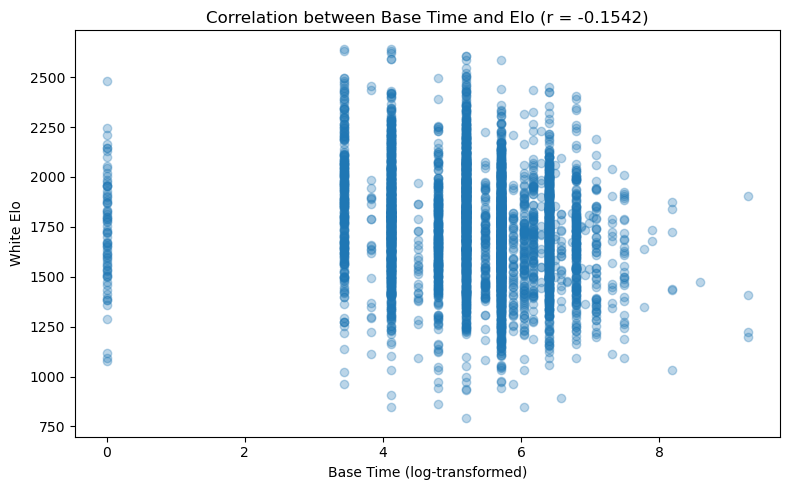


✅ CONCLUSION: We reject H₀ (p-value 0.0000e+00 < 0.05)
There is a significant NEGATIVE correlation: higher Elo players tend to play shorter games.


In [137]:
# Calculating Pearson correlation between base_time and WhiteElo
# Note: base_time was transformed with log1p, so we use the transformed data
correlation_coef, p_value_corr = stats.pearsonr(data['base_time'], data['WhiteElo'])

print(f"Pearson correlation coefficient (r): {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(data['base_time'].sample(5000, random_state=42), 
            data['WhiteElo'].sample(5000, random_state=42), alpha=0.3)
plt.xlabel('Base Time (log-transformed)')
plt.ylabel('White Elo')
plt.title(f'Correlation between Base Time and Elo (r = {correlation_coef:.4f})')
plt.tight_layout()
plt.savefig(IMG_DIR / '10_h2_basetime_elo_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

alpha = 0.05
if p_value_corr < alpha:
    print(f"\n✅ CONCLUSION: We reject H₀ (p-value {p_value_corr:.4e} < {alpha})")
    if correlation_coef > 0:
        print("There is a significant POSITIVE correlation: higher Elo players tend to play longer games.")
    else:
        print("There is a significant NEGATIVE correlation: higher Elo players tend to play shorter games.")
else:
    print(f"\n❌ CONCLUSION: We fail to reject H₀ (p-value {p_value_corr:.4e} >= {alpha})")
    print("There is no evidence of significant correlation between base time and Elo.")

### Hypothesis 3: White's First-Move Advantage in Chess

**Question**: Does White have a statistical advantage over Black? Is the proportion of White wins greater than 50%?

- **H₀ (Null Hypothesis)**: The proportion of White wins (excluding draws) equals 50% (p = 0.5)
- **H₁ (Alternative Hypothesis)**: The proportion of White wins is greater than 50% (p > 0.5)

**Test**: One-tailed Z-test for proportions (α = 0.05)

In [138]:
# Counting wins (excluding draws: Result=1)
white_wins = (data['Result'] == 2).sum()  # White wins
black_wins = (data['Result'] == 0).sum()  # Black wins
draws = (data['Result'] == 1).sum()       # Draws
total_decisive = white_wins + black_wins  # Total decisive games

prop_white_wins = white_wins / total_decisive

print(f"Total games: {len(data)}")
print(f"White wins: {white_wins} ({100*white_wins/len(data):.1f}%)")
print(f"Black wins: {black_wins} ({100*black_wins/len(data):.1f}%)")
print(f"Draws: {draws} ({100*draws/len(data):.1f}%)")
print(f"\nProportion of White wins (decisive games): {prop_white_wins:.4f}")

# H0: p = 0.5, H1: p > 0.5
z_stat, p_value_prop = proportions_ztest(count=white_wins, 
                                          nobs=total_decisive, 
                                          value=0.5, 
                                          alternative='larger')

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value (one-tailed): {p_value_prop:.4e}")

alpha = 0.05
if p_value_prop < alpha:
    print(f"\n✅ CONCLUSION: We reject H₀ (p-value {p_value_prop:.4e} < {alpha})")
    print(f"White has a statistically significant advantage ({prop_white_wins*100:.2f}% wins in decisive games).")
else:
    print(f"\n❌ CONCLUSION: We fail to reject H₀ (p-value {p_value_prop:.4e} >= {alpha})")
    print("There is not enough evidence of White's advantage.")

Total games: 499896
White wins: 249227 (49.9%)
Black wins: 231669 (46.3%)
Draws: 19000 (3.8%)

Proportion of White wins (decisive games): 0.5183

Z-statistic: 25.3361
P-value (one-tailed): 6.4002e-142

✅ CONCLUSION: We reject H₀ (p-value 6.4002e-142 < 0.05)
White has a statistically significant advantage (51.83% wins in decisive games).


### Summary of Hypothesis Tests

| Hypothesis | Statistical Test | Variables | Decision |
|------------|------------------|-----------|----------|
| H1: Elo difference by result | Independent t-test | WhiteElo ~ Result | See result above |
| H2: Time-skill correlation | Pearson correlation | base_time vs WhiteElo | See result above |
| H3: White's advantage | Z-test for proportions | Proportion of White wins | See result above |